In [2]:
import matplotlib.pyplot as plt
import numpy as np
import  scipy.stats

In [16]:
from astroML.datasets import fetch_dr7_quasar
import astropy

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

astropy.cosmology.Planck18

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)

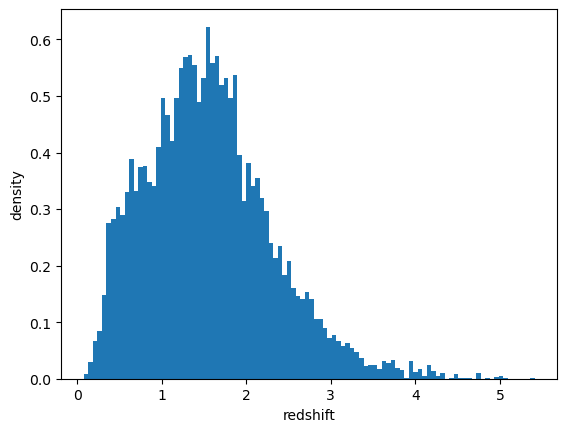

In [17]:
plt.hist(z,bins=100, density=True)
plt.ylabel("density")
plt.xlabel("redshift");

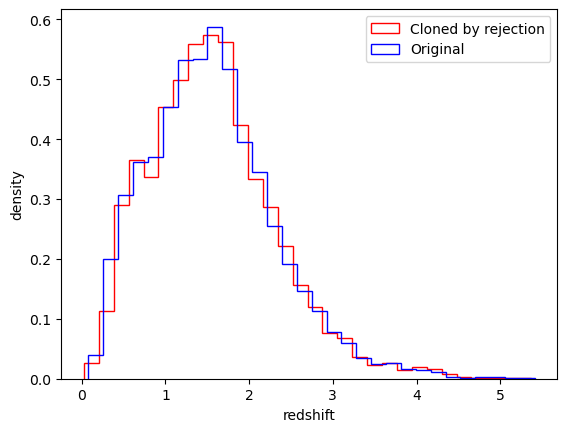

In [18]:
counts, bins = np.histogram(z, bins=100, density=True)

N=10000
good_x=[]
good_y=[]

while len(good_x) < N:
    x=np.random.uniform(0,bins.max())
    y=np.random.uniform(0,counts.max())
    idx = np.searchsorted(bins, x)-1
    if y < counts[idx]:
        good_x.append(x)
        good_y.append(y)

plt.hist(good_x,bins=30, density=True, histtype='step', color='r', label='Cloned by rejection')
plt.hist(z,bins=30, density=True, histtype='step', color='b', label='Original')
plt.ylabel("density")
plt.xlabel("redshift")
plt.legend();

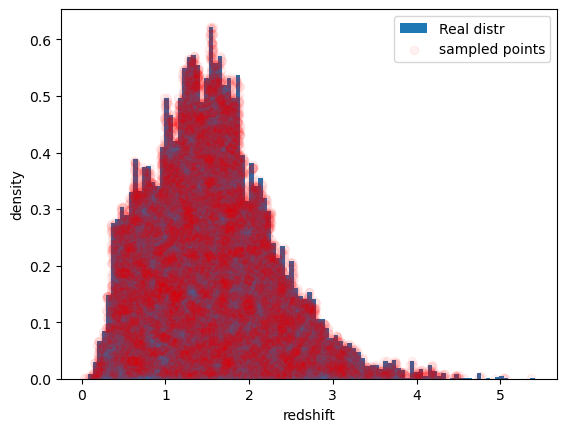

In [22]:
plt.hist(z,bins=100, density=True, label='Real distr')
plt.scatter(good_x, good_y, color='r', alpha=0.05, label='sampled points')
plt.legend()
plt.ylabel("density")
plt.xlabel("redshift");

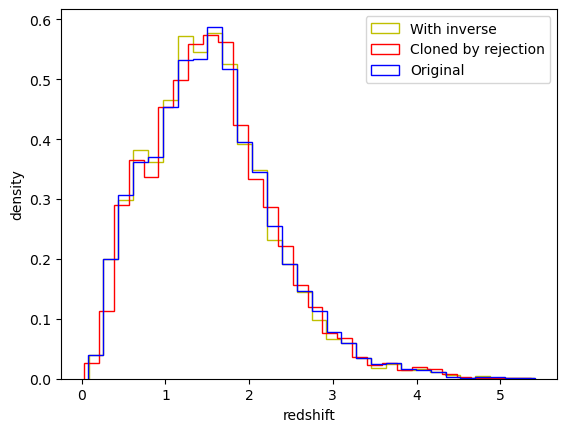

In [23]:
# acommualtive function xd 

u=np.random.uniform(0,1,N)
disth = scipy.stats.rv_histogram((counts,bins))
y=disth.ppf(u)
plt.hist(y,bins=30,density=True,histtype='step',color='y',label='With inverse')
plt.hist(good_x,bins=30, density=True, histtype='step', color='r', label='Cloned by rejection')
plt.hist(z,bins=30, density=True, histtype='step', color='b', label='Original')
plt.ylabel("density")
plt.xlabel("redshift")
plt.legend();

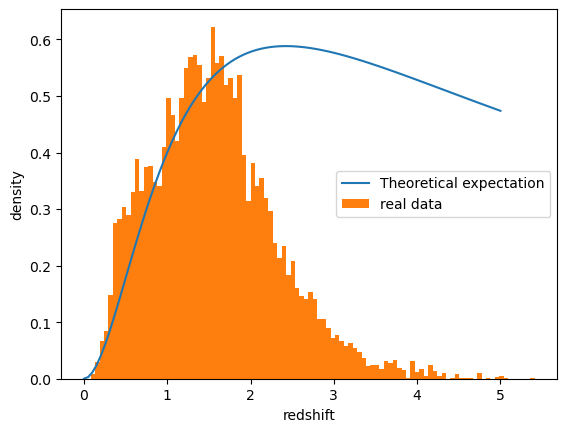

In [24]:
z_vals = np.linspace(0,5,100)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value 

plt.plot(z_vals, comvol/(1.7*comvol.max()), label="Theoretical expectation")
plt.hist(z, bins=100, density=True, label="real data")
plt.legend()
plt.ylabel("density")
plt.xlabel("redshift");